In [469]:
import numpy as np
import pandas as pd
import seaborn as sns
from faker import Faker
import secrets

In [470]:
# generate random int for seed
# my_seed = secrets.randbits(32)
my_seed = 3195246896
print(my_seed)

# Use the generated seed to initialize a NumPy generator
np.random.seed(my_seed)

Faker.seed(my_seed)
fake = Faker()
# fake.seed(my_seed)

3195246896


## aquire or generate data

In [471]:
n=100
names = [fake.first_name() for _ in range(n)]
# names

salaries = np.random.exponential(scale=20000, size=n) + 30000 # Add base salary
# sns.histplot(salaries)

In [472]:
fake_data = pd.DataFrame({
    "Name":names,
    "Salary":salaries
})
fake_data.head()

,Name,Salary
0,Nicholas,51679.385368
1,Rodney,33864.122160
2,Ryan,41331.531247
3,Paul,47626.834671
4,Shannon,49049.494766


## mess it up

turn salary into messy strings

In [473]:
fake_data['Salary'] = '$' + fake_data['Salary'].astype(str)
fake_data['Salary'] = fake_data['Salary'].str.replace('.',',')

fake_data.head()

,Name,Salary
0,Nicholas,"$51679,38536783932"
1,Rodney,"$33864,12215982051"
2,Ryan,"$41331,531247461346"
3,Paul,"$47626,83467071775"
4,Shannon,"$49049,494766370386"


In [474]:
# Randomly replace 10% of values with NaN across the entire DataFrame
frac_nan = 0.1

indices = fake_data.sample(frac=frac_nan).index

# pick random value from cols
fake_data.loc[indices, 'Salary'] = "-"

fake_data.head()

,Name,Salary
0,Nicholas,"$51679,38536783932"
1,Rodney,"$33864,12215982051"
2,Ryan,"$41331,531247461346"
3,Paul,-
4,Shannon,"$49049,494766370386"


## write and read CSV

* on read, any blank space (or pd.NA) will be converted to NaN
* but if there are other characters, we need to take care of that

In [ ]:
fake_data.to_csv("../data/fake_data.csv")
fake_data = pd.read_csv("../data/fake_data.csv")
fake_data.head()

,Unnamed: 0,Name,Salary
0,0,Nicholas,"$51679,38536783932"
1,1,Rodney,"$33864,12215982051"
2,2,Ryan,"$41331,531247461346"
3,3,Paul,-
4,4,Shannon,"$49049,494766370386"


## clean it

Salary is now an "object" (not numeric), so we can't do any analysis until we clean it

In [476]:
fake_data.dtypes

Unnamed: 0     int64
Name          object
Salary        object
dtype: object

In [477]:
# replace will find and replace a whole cell value (not a substring)
fake_data['Salary'] = fake_data['Salary'].replace('-',np.nan)
fake_data.head()

,Unnamed: 0,Name,Salary
0,0,Nicholas,"$51679,38536783932"
1,1,Rodney,"$33864,12215982051"
2,2,Ryan,"$41331,531247461346"
3,3,Paul,NaN
4,4,Shannon,"$49049,494766370386"


In [478]:
fake_data['Salary'] = fake_data['Salary'].str.replace('$','')
fake_data['Salary'] = fake_data['Salary'].str.replace(',','.')
fake_data.head()

,Unnamed: 0,Name,Salary
0,0,Nicholas,51679.38536783932
1,1,Rodney,33864.12215982051
2,2,Ryan,41331.531247461346
3,3,Paul,NaN
4,4,Shannon,49049.494766370386


In [479]:
fake_data['Salary'] = fake_data['Salary'].astype(float)
fake_data.dtypes

Unnamed: 0      int64
Name           object
Salary        float64
dtype: object

<Axes: xlabel='Salary', ylabel='Count'>

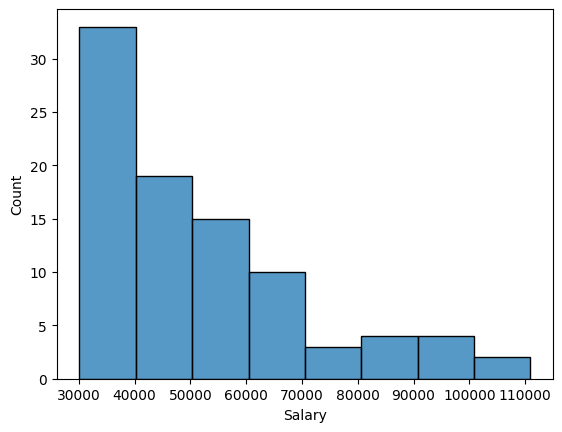

In [480]:
sns.histplot(fake_data['Salary'])

## What about those NaNs?

Options:
1. drop them
2. fill them

In [481]:
fake_data.head()

,Unnamed: 0,Name,Salary
0,0,Nicholas,51679.385368
1,1,Rodney,33864.122160
2,2,Ryan,41331.531247
3,3,Paul,NaN
4,4,Shannon,49049.494766




Dropping data:
- drop rows (default)
- drop columns - in this case, that will drop the only numeric column we're working with!

In [482]:
# drop rows with na's (default)
fd_drop_rows = fake_data.dropna(axis = 'index')
fd_drop_rows.head()

,Unnamed: 0,Name,Salary
0,0,Nicholas,51679.385368
1,1,Rodney,33864.122160
2,2,Ryan,41331.531247
4,4,Shannon,49049.494766
5,5,Angela,61094.535062


Filling:
- fill with specific value
- backward fill - fill with next value
- forward fill - fill with previous value

In [483]:
# fill with value
fd_zfill = fake_data.fillna(0) # probably don't want this

fd_bfill = fake_data.bfill()
fd_bfill.head()

fd_ffill = fake_data.ffill()
fd_ffill.head()

,Unnamed: 0,Name,Salary
0,0,Nicholas,51679.385368
1,1,Rodney,33864.122160
2,2,Ryan,41331.531247
3,3,Paul,41331.531247
4,4,Shannon,49049.494766


filling with aggregates

In [484]:
x = fake_data['Salary'].mean()
fd_mean_fill = fake_data.fillna(x)
fd_mean_fill.head()

,Unnamed: 0,Name,Salary
0,0,Nicholas,51679.385368
1,1,Rodney,33864.122160
2,2,Ryan,41331.531247
3,3,Paul,51484.164947
4,4,Shannon,49049.494766
